# One Equation, Two Cancer Stories
### The Cauchy–Euler equation, from tumor spheroids to drug-binding simulations (Julia)

This notebook is for a student taking a first course in ordinary differential equations (ODEs) who wants to see where the **Cauchy–Euler equation** shows up in cancer research, and how it connects to work at **Memorial Sloan Kettering Cancer Center (MSK)**.

**The honest framing first.** The Cauchy–Euler equation is not a step in cancer *genomics* pipelines. A search of all public repositories under [github.com/mskcc](https://github.com/mskcc) (October 2026) found genomics and clinical-data tools, but no differential-equation models. The equation lives one layer down, in the **physics** that cancer researchers use:

* It is the equation for anything that **spreads out evenly from a center in 3-D**. Written for a function of the radius $r$, the 3-D Laplacian of a radially symmetric function is $\nabla^2 y = y'' + \tfrac{2}{r}y'$, and setting it to zero and multiplying by $r^2$ gives the Cauchy–Euler equation
$$
r^2 y'' + 2r\,y' = 0 .
$$
* **Story 1, tumor biology:** oxygen soaking into a ball of cancer cells (a *tumor spheroid*). This explains why larger spheroids develop low-oxygen (**hypoxic**) zones and a dead (**necrotic**) core. Hypoxia matters clinically: MSK radiation oncologists have used hypoxia imaging to decide how much radiation a patient receives.
* **Story 2, drug discovery:** the electric potential around a charged atom, which falls off as $1/r$. That $1/r$ term is in every molecular-dynamics simulation of a drug binding a cancer protein, including **OpenMM**, the simulation engine co-developed by John Chodera's lab at MSK's Sloan Kettering Institute. Section 4 applies it to a real cancer protein: the **ABL kinase**, the target of the leukemia drug imatinib (Gleevec).

**Contents**
0. Cauchy beyond this equation: a quick tour of his results in Calc 2, Calc 3, linear algebra and ODEs
1. The Cauchy–Euler method: three worked examples
2. Story 1: Oxygen in a tumor spheroid (with an animated model)
3. Story 2: The $1/r$ potential, Born solvation and OpenMM at MSK
4. A real cancer protein: the ABL kinase and imatinib (with a rotating 3-D model)
5. Wrap-up: one equation, two stories, and where else the equation appears in computational biology
6. Exercises
7. References

Every section opens with a **Pre-understanding** box (what to have in mind before starting) and closes with a **Post-understanding** box (a summary of what the section established).

**Traffic-light guide.** Short notes marked with a light show where each idea is usually taught, for a reader partway through a first ODE course:
* 🟢 **Already familiar:** calculus, linear algebra or early in a first ODE course (second-order linear equations, undetermined coefficients, the Cauchy–Euler equation).
* 🟡 **Coming later in a first ODE course:** systems of first-order equations, boundary-value problems, power-series (Frobenius) solutions and an introduction to partial differential equations.
* 🔴 **From another course:** physics, chemistry, real analysis or numerical methods. Each 🔴 idea is explained where it is used, so nothing needs to be looked up first.

**Prerequisites:** single-variable calculus, solving constant-coefficient second-order ODEs, basic Julia (or Python; the syntax is close).
**Packages:** `OrdinaryDiffEqTsit5` (the lightweight SciML package that provides the `Tsit5` solver), `Plots` and the standard library `LinearAlgebra`.

In [1]:
# One-time install (uncomment if needed):
# import Pkg; Pkg.add(["OrdinaryDiffEqTsit5", "Plots"])

using OrdinaryDiffEqTsit5   # SciML ODE solver subpackage (provides ODEProblem, solve, Tsit5)
using LinearAlgebra         # dot, norm, det, eigvals
using Plots
using Random
default(size = (720, 380), legend = :best, lw = 2, bottom_margin = 5Plots.mm, left_margin = 3Plots.mm)
Random.seed!(1789)          # Cauchy's birth year, for reproducible random checks

TaskLocalRNG()

## 0. Cauchy beyond this equation

> **Pre-understanding.** Augustin-Louis Cauchy (1789–1857) wrote 789 mathematics papers ([MacTutor](https://mathshistory.st-andrews.ac.uk/Biographies/Cauchy/)), so his name appears all over the undergraduate sequence. A student who meets "Cauchy" in an ODE course has usually already used several of his results without the name attached. This section lines them up by course, and the code below checks a few of them numerically.

| | Course | Result | What it says |
|---|---|---|---|
| 🟢 | Calc 1–2 | **Rigorous limits and series** | His *Cours d'analyse* (1821) set out to develop "the basic theorems of the calculus as rigorously as possible" and was the first rigorous study of when infinite series converge ([MacTutor](https://mathshistory.st-andrews.ac.uk/Biographies/Cauchy/)). |
| 🔴 | Calc 1–2 | **Cauchy mean value theorem** | If $f, g$ are continuous on $[a,b]$ and differentiable inside, some $c$ has $\big(f(b)-f(a)\big)g'(c) = \big(g(b)-g(a)\big)f'(c)$. It is the standard tool for proving **L'Hôpital's rule**. |
| 🟢 | Calc 2 | **Root test** | If $\lim \sqrt[n]{\lvert a_n\rvert} = L$, the series $\sum a_n$ converges when $L<1$ and diverges when $L>1$. First published by Cauchy in the *Cours d'analyse* ([Wikipedia: Root test](https://en.wikipedia.org/wiki/Root_test)). |
| 🔴 | Calc 2 | **Condensation test** | For non-increasing $f(n) \ge 0$: $\sum f(n)$ converges if and only if $\sum 2^n f(2^n)$ does. Applied to $\sum 1/n$ it gives $\sum 1$, which diverges ([Wikipedia](https://en.wikipedia.org/wiki/Cauchy_condensation_test)). |
| 🔴 | Calc 2 / analysis | **Cauchy sequences** | A sequence whose terms eventually stay arbitrarily close *to each other*. In the real numbers, these are exactly the convergent sequences, which lets one prove convergence without knowing the limit. |
| 🟢 | Calc 3 and linear algebra | **Cauchy–Schwarz inequality** | $\lvert \mathbf u\cdot\mathbf v\rvert \le \lVert\mathbf u\rVert\,\lVert\mathbf v\rVert$. This is why $\cos\theta = \dfrac{\mathbf u\cdot\mathbf v}{\lVert\mathbf u\rVert\lVert\mathbf v\rVert}$ always lands in $[-1,1]$. Cauchy proved the version for sums in 1821; Bunyakovsky (1859) and Schwarz (1888) gave the integral version ([Wikipedia](https://en.wikipedia.org/wiki/Cauchy%E2%80%93Schwarz_inequality)). |
| 🟢 | Linear algebra | **Determinants** | Cauchy used "determinant" in its modern sense in 1812, and in 1812 gave the first proof of the product theorem $\det(AB)=\det A\,\det B$ (Binet presented a proof the same day) ([MacTutor: Matrices and determinants](https://mathshistory.st-andrews.ac.uk/HistTopics/Matrices_and_determinants/)). |
| 🟢 | Linear algebra | **Eigenvalues** | Working on quadratic forms in 1826, Cauchy found eigenvalues, showed that similar matrices have the same characteristic equation and proved that every real symmetric matrix is diagonalizable (same source). |
| 🟢 | ODEs | **The Cauchy problem / Cauchy–Lipschitz theorem** | "Cauchy problem" is another name for an initial-value problem. The existence-and-uniqueness theorem is also called the Cauchy–Lipschitz (Picard–Lindelöf) theorem ([Wikipedia](https://en.wikipedia.org/wiki/Picard%E2%80%93Lindel%C3%B6f_theorem)). |
| 🟢 | ODEs | **Cauchy–Euler equation** | Despite the name, Euler studied these equations first, with a notable treatment in his *Institutiones calculi integralis* (1768); the equation is also called Euler's equation or the equidimensional equation ([Wikipedia](https://en.wikipedia.org/wiki/Cauchy%E2%80%93Euler_equation)). |

In [2]:
# Numerical sanity checks of four of Cauchy's results.

# 1) Cauchy–Schwarz: |u⋅v| / (‖u‖‖v‖) never exceeds 1 (100,000 random pairs in R^5).
worst = maximum(abs(dot(u, v)) / (norm(u) * norm(v)) for (u, v) in ((randn(5), randn(5)) for _ in 1:100_000))
println("Cauchy–Schwarz: largest |u⋅v|/(‖u‖‖v‖) seen = ", round(worst, digits = 6), "  (must be ≤ 1)")

# 2) Determinant product theorem: det(AB) = det(A) det(B).
A, B = randn(4, 4), randn(4, 4)
println("det(AB) - det(A)det(B) = ", det(A * B) - det(A) * det(B))

# 3) Real symmetric matrices have real eigenvalues (and are diagonalizable).
S = A + A'                                   # symmetric
λ = eigvals(S)
println("eigenvalues of a random symmetric matrix: ", round.(λ, digits = 3), "  (all real: ", eltype(λ) <: Real, ")")

# 4) Root test on Σ n/2^n: the n-th root of n/2^n tends to 1/2 < 1, so the series converges (to 2).
for n in (10, 100, 1000)
    println("n = $n:  (n/2^n)^(1/n) = ", round(Float64((n / big(2)^n)^(1 / n)), digits = 5))
end
println("partial sum of n/2^n up to n = 60: ", sum(n / 2.0^n for n in 1:60))

Cauchy–Schwarz: largest |u⋅v|/(‖u‖‖v‖) seen = 0.996448

  (must be ≤ 1)
det(AB) - det(A)det(B) = -1.2212453270876722e-15


eigenvalues of a random symmetric matrix: 

[-6.335, -4.144, -1.228, 0.346]  (all real: true)
n = 10:  (n/2^n)^(1/n) = 0.62946
n = 100:  (n/2^n)^(1/n) = 0.52356
n = 1000:  (n/2^n)^(1/n) = 0.50347
partial sum of n/2^n up to n = 60: 1.9999999999999998


> **Post-understanding (summary).** Cauchy's name marks several turning points of the undergraduate sequence: rigorous convergence (Calc 2), the inequality behind angles between vectors (Calc 3), determinants and eigenvalues (linear algebra) and initial-value problems (ODEs). The equation that carries his name in the ODE course was actually studied first by Euler. The checks above confirm four of these results numerically: Cauchy–Schwarz never exceeds 1, $\det(AB)=\det A\det B$ up to rounding error, a random symmetric matrix has real eigenvalues and the root test correctly predicts that $\sum n/2^n$ converges.

## 1. The Cauchy–Euler method

> 🟢 **Pre-understanding.** For constant-coefficient equations such as $y'' - 3y' + 2y = 0$, the standard move is to guess $y = e^{rt}$, because differentiating an exponential returns the same exponential. A Cauchy–Euler equation has *variable* coefficients, but in a special pattern: **each power of $x$ matches the order of the derivative**,
> $$ x^2 y'' + a\,x\,y' + b\,y = 0 \qquad (x > 0). $$
> Every term has the same "scale": stretching $x \to cx$ leaves the equation unchanged. That is why it is also called *equidimensional*, and it suggests guessing a function that keeps its shape under scaling: a **power**, $y = x^m$.

### 1.1 The method
Substitute $y = x^m$, $y' = m x^{m-1}$, $y'' = m(m-1)x^{m-2}$:
$$
x^2 \cdot m(m-1)x^{m-2} + a x \cdot m x^{m-1} + b x^m = \big[m(m-1) + a m + b\big]\,x^m = 0 .
$$
Since $x^m \neq 0$, the exponent must solve the **indicial equation**
$$
m(m-1) + a\,m + b = 0 \quad\Longleftrightarrow\quad m^2 + (a-1)m + b = 0 .
$$

| Roots of the indicial equation | General solution ($x>0$) |
|---|---|
| Two distinct real roots $m_1 \neq m_2$ | $y = c_1 x^{m_1} + c_2 x^{m_2}$ |
| One repeated root $m$ | $y = c_1 x^{m} + c_2 x^{m}\ln x$ |
| Complex roots $\alpha \pm \beta i$ | $y = x^{\alpha}\big(c_1\cos(\beta\ln x) + c_2\sin(\beta\ln x)\big)$ |

### 1.2 Why $\ln x$ appears: the substitution $x = e^t$
Let $t = \ln x$ and $Y(t) = y(e^t)$. The chain rule gives $x\,y' = \dfrac{dY}{dt}$ and $x^2 y'' = \dfrac{d^2Y}{dt^2} - \dfrac{dY}{dt}$, so the equation becomes
$$
Y'' + (a-1)\,Y' + b\,Y = 0,
$$
an ordinary **constant-coefficient** equation with the *same* characteristic polynomial as the indicial equation. Its solutions $e^{mt}$, $t\,e^{mt}$ and $e^{\alpha t}\cos\beta t$ translate back to $x^m$, $x^m \ln x$ and $x^\alpha\cos(\beta\ln x)$. A Cauchy–Euler equation is a constant-coefficient equation in disguise, viewed on a logarithmic scale.

### 1.3 Three worked examples (by hand)
Each uses the initial conditions $y(1) = 1$, $y'(1) = 0$.

**Example A (distinct real roots): $x^2y'' + xy' - 4y = 0$.** Here $a = 1$, $b = -4$: $m^2 - 4 = 0$, so $m = \pm 2$ and $y = c_1x^2 + c_2x^{-2}$. The conditions give $c_1 + c_2 = 1$ and $2c_1 - 2c_2 = 0$, so
$$ y_A = \tfrac12\left(x^2 + x^{-2}\right). $$

**Example B (repeated root): $x^2y'' - 3xy' + 4y = 0$.** Here $m^2 - 4m + 4 = (m-2)^2 = 0$, so $y = x^2(c_1 + c_2\ln x)$. Then $y(1) = c_1 = 1$ and $y'(1) = 2c_1 + c_2 = 0$, so
$$ y_B = x^2\,(1 - 2\ln x). $$

**Example C (complex roots): $x^2y'' + xy' + 9y = 0$.** Here $m^2 + 9 = 0$, so $m = \pm 3i$ ($\alpha = 0$, $\beta = 3$) and $y = c_1\cos(3\ln x) + c_2\sin(3\ln x)$. Then $y(1) = c_1 = 1$ and $y'(1) = 3c_2 = 0$, so
$$ y_C = \cos(3\ln x). $$
The oscillation is evenly spaced in $\ln x$, not in $x$: each cycle takes $x$ to $e^{2\pi/3} \approx 8.1$ times its previous value.

The code below solves all three initial-value problems numerically, without using the formulas, and compares.

> 🟡 **Coming later: systems.** To use a numerical solver, the second-order equation is rewritten as a first-order *system* for the pair $u = (y, y')$: $u_1' = u_2$ and $u_2' = -(a x u_2 + b u_1)/x^2$. Systems of first-order equations are usually taught later in a first ODE course; here the trick is only used to hand the equation to the solver.

A: x²y'' + xy' - 4y = 0      max relative error (numerical vs. hand solution) = 

1.4841114924710552e-11
B: x²y'' - 3xy' + 4y = 0     max relative error (numerical vs. hand solution) = 

1.1172087627586963e-11
C: x²y'' + xy' + 9y = 0      max relative error (numerical vs. hand solution) = 

1.0311161993681317e-10


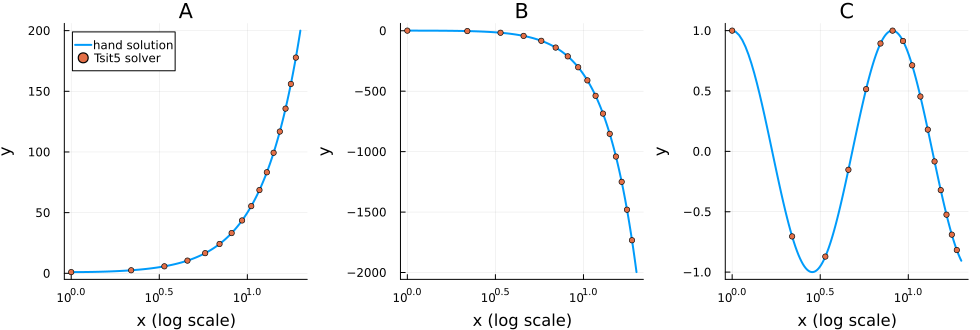

In [3]:
# Write x²y'' + a x y' + b y = 0 as a first-order system u = (y, y') and solve it numerically from x = 1.
euler_rhs(a, b) = (u, p, x) -> [u[2], -(a * x * u[2] + b * u[1]) / x^2]

examples = [
    ("A: x²y'' + xy' - 4y = 0",  1.0, -4.0, x -> (x^2 + x^-2) / 2),
    ("B: x²y'' - 3xy' + 4y = 0", -3.0, 4.0, x -> x^2 * (1 - 2log(x))),
    ("C: x²y'' + xy' + 9y = 0",  1.0,  9.0, x -> cos(3log(x))),
]

plts = []
for (name, a, b, exact) in examples
    prob = ODEProblem(euler_rhs(a, b), [1.0, 0.0], (1.0, 20.0))
    sol  = solve(prob, Tsit5(), reltol = 1e-10, abstol = 1e-10)
    xs   = range(1, 20, length = 400)
    err  = maximum(abs(sol(x)[1] - exact(x)) / max(1, abs(exact(x))) for x in xs)
    println(rpad(name, 28), " max relative error (numerical vs. hand solution) = ", err)
    p = plot(xs, exact.(xs), label = "hand solution", xscale = :log10, title = first(name, 1),
             xlabel = "x (log scale)", ylabel = "y", legend = first(name, 1) == "A" ? :topleft : false)
    scatter!(p, xs[1:25:end], [sol(x)[1] for x in xs[1:25:end]], ms = 3, label = "Tsit5 solver")
    push!(plts, p)
end
plot(plts..., layout = (1, 3), size = (980, 330))

**The equation behind both cancer stories.** For a radially symmetric function in 3-D, the Laplacian is $\nabla^2 y = \dfrac{1}{r^2}\dfrac{d}{dr}\!\left(r^2\dfrac{dy}{dr}\right) = y'' + \dfrac{2}{r}y'$. Setting it to zero and multiplying by $r^2$:
$$
r^2 y'' + 2r\,y' = 0 \qquad (a = 2,\ b = 0) \;\Longrightarrow\; m(m-1) + 2m = m(m+1) = 0 \;\Longrightarrow\; m = 0,\ -1,
$$
$$
\boxed{\,y(r) = A + \dfrac{B}{r}\,}
$$
A constant, plus a term that falls off like $1/r$. Sections 2 and 3 are two physical readings of this one formula.

> **Post-understanding (summary).** A Cauchy–Euler equation $x^2y'' + axy' + by = 0$ is solved by guessing $y = x^m$, which turns the ODE into the quadratic indicial equation $m^2 + (a-1)m + b = 0$. Distinct roots give two powers, a repeated root adds a $\ln x$ factor and complex roots give oscillations in $\ln x$. The substitution $x = e^t$ explains all three cases: it converts the equation into a constant-coefficient one. The numerical solver matched all three hand solutions to within about $10^{-10}$ (relative error). The special case $r^2y'' + 2ry' = 0$, the 3-D radial Laplace equation, has solutions $1$ and $1/r$.

## 2. Story 1: Oxygen in a tumor spheroid

> **Pre-understanding: the biology.** A **multicellular tumor spheroid** is a small ball of cancer cells grown in the lab. Grimes et al. (2014) describe spheroids as "a bridge between standard two-dimensional monolayer cultures and in vivo models": they are three-dimensional aggregates of cancer cells that, "beyond the diffusion distance of oxygen, naturally form regions of hypoxia." A spheroid has no blood vessels, so its cells get oxygen only by **diffusion** in from the surrounding medium, and every cell along the way **consumes** some. Large spheroids therefore develop three zones (Greenspan 1972; Grimes et al. 2014): a well-oxygenated **proliferating rim**, a **hypoxic** (low-oxygen) layer and a dead **necrotic core**.
>
> **Why hypoxia matters.** In tumors, hypoxia "is associated with poor prognosis, increased likelihood of metastasis and resistance to therapy," and "it has been known since the 1950s that hypoxic tissue is more radioresistant than well-oxygenated tissue" (Grimes et al. 2014). This is clinical at MSK: in a phase II trial, MSK radiation oncologists imaged tumor hypoxia with **FMISO PET** in patients with HPV-related oropharyngeal (throat) cancer. Patients whose tumors were *not* hypoxic received 30 Gy of radiation over 3 weeks instead of the standard 70 Gy over 7 weeks. The study reported 2-year locoregional control of 94.7%, meeting its objective, with fewer severe side effects (Lee et al., *J Clin Oncol*, doi:10.1200/JCO.23.01308). (For the biology of hypoxia and angiogenesis, see Weinberg, *The Biology of Cancer*, 3rd ed., Chapter 13.)
>
> **Pre-understanding: the math.** Steady state means oxygen flowing in balances oxygen consumed. With a constant consumption rate in living tissue, the oxygen partial pressure $p(r)$ satisfies a **Poisson equation** (Grimes et al. 2014, eqs. 2.1–2.4): $\nabla^2 p = \kappa$, where $\kappa > 0$ combines the consumption rate and the diffusion constant. In radial form, multiplied by $r^2$:
> $$ r^2p'' + 2r\,p' = \kappa\, r^2 . $$
> The left side is the Cauchy–Euler operator from Section 1; the right side makes it **nonhomogeneous**.
>
> 🔴 **From another course: the Laplacian and Poisson's equation.** $\nabla^2$ (the Laplacian) and equations such as $\nabla^2 p = \kappa$ belong to vector calculus and partial differential equations; a first ODE course reaches them only in a short introduction to PDEs at the end. Only the radial formula $\nabla^2 p = p'' + \tfrac{2}{r}p'$ is needed here, and it turns the problem into an ordinary ODE.

### 2.1 Solving it
* **Homogeneous part** (Section 1): $p_h = A + B/r$.
* 🟢 **Particular solution (undetermined coefficients):** the right side is a power, $\kappa r^2$, so guess $p_p = Cr^2$: $r^2(2C) + 2r(2Cr) = 6Cr^2 = \kappa r^2$, so $C = \kappa/6$. (This works because $m = 2$ is not a root of the indicial equation $m(m+1) = 0$.)

$$
p(r) = A + \frac{B}{r} + \frac{\kappa}{6}\,r^2 .
$$

> 🟡 **Coming later: boundary-value problems.** The conditions below are set at two *different* places (the center or the edge of the dead core, and the surface), not at one starting point. That makes this a **boundary-value problem**, usually taught near the end of a first ODE course. The recipe is the same as for an initial-value problem: write the general solution, then solve for the constants.

**Case 1: small spheroid, no necrotic core.** The oxygen level must stay finite at the center, so $B = 0$: the $1/r$ solution is thrown out. The surface touches the medium, so $p(R) = p_0$:
$$
p(r) = p_0 - \frac{\kappa}{6}\,(R^2 - r^2), \qquad p(0) = p_0 - \frac{\kappa R^2}{6}.
$$
The center runs out of oxygen exactly when $R$ reaches the **diffusion limit**
$$
r_l = \sqrt{6p_0/\kappa} \qquad\text{(Grimes et al. 2014, eq. 2.6).}
$$

**Case 2: large spheroid, $R > r_l$, with a necrotic core of radius $r_n$.** Now the living tissue is the shell $r_n \le r \le R$, and $r = 0$ is no longer part of the domain, so **the $1/r$ solution comes back**. At the edge of the dead core, oxygen has just run out and no oxygen flows into the core: $p(r_n) = 0$ and $p'(r_n) = 0$. Solving:
$$
p'(r_n) = -\frac{B}{r_n^2} + \frac{\kappa}{3}r_n = 0 \;\Rightarrow\; B = \frac{\kappa r_n^3}{3},
\qquad
p(r_n) = 0 \;\Rightarrow\; A = -\frac{\kappa r_n^2}{2}.
$$
The surface condition $p(R) = p_0$ then fixes $r_n$. Multiplying through by $6R/\kappa$:
$$
R^3 - 3R\,r_n^2 + 2r_n^3 = r_l^2\,R .
$$
**Check against the literature.** Writing $w = R - r_n$ for the thickness of the living rim, this becomes $2w^3 - 3Rw^2 + r_l^2R = 0$, which is eq. 2.5 of Grimes et al. (2014). Their eq. 2.4 gives the same oxygen profile as the formula here. For a very large spheroid the rim thickness tends to $r_l/\sqrt3$ (their eq. 2.10): deep inside a big tumor, oxygen penetrates only a fixed distance.

### 2.2 Real numbers
Grimes et al. (2014) grew DLD1 colorectal-cancer spheroids in medium at $p_0 = 100$ mmHg and measured a diffusion limit of $r_l = 233 \pm 22$ µm, consistent across spheroids. They took about 10 mmHg as the hypoxia threshold (where the hypoxia marker EF5 binds maximally). These three numbers set $\kappa = 6p_0/r_l^2$, and everything below follows from them.

> 🔴 **From another course: bisection.** The cubic for $r_n$ is solved numerically by **bisection** (numerical methods): the cubic is positive at $r_n = 0$ and negative at $r_n = R$, so the code repeatedly halves the interval, keeping the half where the sign changes.

In [4]:
# Parameters from Grimes et al. (2014)
const p0   = 100.0               # mmHg, oxygen partial pressure in the medium
const rl   = 233.0               # µm, measured diffusion limit
const phyp = 10.0                # mmHg, hypoxia threshold
const κ    = 6p0 / rl^2          # mmHg/µm², consumption ÷ diffusion

# Necrotic-core radius: root of R³ - 3R rn² + 2rn³ - rl² R = 0 on (0, R), by bisection.
function necrotic_radius(R)
    R <= rl && return 0.0
    f(x) = R^3 - 3R * x^2 + 2x^3 - rl^2 * R          # f(0) > 0 and f(R) < 0 when R > rl
    lo, hi = 0.0, R
    for _ in 1:200
        mid = (lo + hi) / 2
        f(mid) > 0 ? (lo = mid) : (hi = mid)
    end
    (lo + hi) / 2
end

# Oxygen profile p(r) for a spheroid of radius R (both cases).
function pO2(r, R)
    rn = necrotic_radius(R)
    rn == 0 && return p0 - κ / 6 * (R^2 - r^2)                       # case 1
    r < rn ? 0.0 : p0 + κ / 6 * (r^2 - R^2 + 2rn^3 * (1 / r - 1 / R))  # case 2 (Grimes eq. 2.4)
end

# Radius where oxygen first rises above the hypoxia threshold (the hypoxic boundary).
# Returns 0 when the whole spheroid is above 10 mmHg (no hypoxic zone).
hypoxic_radius(R) = (rs = range(0, R, length = 20_001); rs[findfirst(r -> pO2(r, R) >= phyp, rs)])

println("κ = ", round(κ, sigdigits = 4), " mmHg/µm²")
println("Center first becomes hypoxic at R = rl·√(1 - 10/100) = ", round(rl * sqrt(1 - phyp / p0), digits = 1), " µm")
println()
println(rpad("R (µm)", 9), rpad("center pO2", 12), rpad("necrotic r_n", 14), rpad("hypoxic for r <", 17), "living rim R - r_n")
for R in (100, 200, 233, 300, 400, 500, 1000)
    rn = necrotic_radius(R)
    println(rpad(R, 9), rpad(round(pO2(0.0, R), digits = 1), 12), rpad(round(rn, digits = 1), 14),
            rpad((rh = hypoxic_radius(R); rh == 0 ? "none" : round(rh, digits = 1)), 17), round(R - rn, digits = 1))
end
println("\nLarge-spheroid limit of the rim, rl/√3 = ", round(rl / sqrt(3), digits = 1), " µm")

κ = 0.01105 mmHg/µm²
Center first becomes hypoxic at R = rl·√(1 - 10/100) = 221.0 µm

R (µm)   center pO2  necrotic r_n  hypoxic for r <  living rim R - r_n
100      

81.6        0.0           none             100.0
200      26.3        0.0           none             200.0
233      0.0         0.0           73.7             233.0
300      0.0         129.2         176.1            170.8
400      0.0         243.5         288.5            156.5
500      0.0         349.5         393.8            150.5
1000     0.0         858.7         901.9            141.3

Large-spheroid limit of the rim, rl/√3 = 134.5 µm


### 2.3 Checking the formula with an ODE solver
The formula above was derived by hand. As an independent check, the code below integrates $p'' = \kappa - \tfrac{2}{r}p'$ **outward** from the edge of the dead core (starting at $p = 0$, $p' = 0$) and confirms that the numerical solution arrives at exactly $p_0 = 100$ mmHg at the surface. For a spheroid without a core, it starts just off the center with the formula's center value and zero slope.

In [5]:
for R in (150.0, 233.0, 300.0, 500.0)
    rn = necrotic_radius(R)
    r0 = rn > 0 ? rn : 1e-6
    prob = ODEProblem((u, _, r) -> [u[2], κ - 2u[2] / r], [pO2(r0, R), 0.0], (r0, R))
    sol  = solve(prob, Tsit5(), reltol = 1e-10, abstol = 1e-10)
    println("R = $(Int(R)) µm:  surface pO2 from the solver = ", round(sol.u[end][1], digits = 6),
            " mmHg (should be $p0)")
end

R = 150 µm:  surface pO2 from the solver = 100.0

 mmHg (should be 100.0)
R = 233 µm:  surface pO2 from the solver = 100.0 mmHg (should be 100.0)
R = 300 µm:  surface pO2 from the solver = 100.0 mmHg (should be 100.0)
R = 500 µm:  surface pO2 from the solver = 100.0 mmHg (should be 100.0)


### 2.4 The model in motion
The animation grows a spheroid from 40 µm to 450 µm in radius. **Left:** the oxygen profile from the center to the surface. **Right:** a cross-section colored by oxygen level, with the hypoxic boundary (orange dashed circle, 10 mmHg) and the necrotic core (grey disk) once $R$ passes the diffusion limit of 233 µm.

![Growing tumor spheroid: oxygen profile and cross-section](figures/spheroid_oxygen.gif)

The next cell regenerates the GIF (it takes a minute or two) and saves it to `figures/spheroid_oxygen.gif`.

Plots.AnimatedGif("figures/spheroid_oxygen.gif")
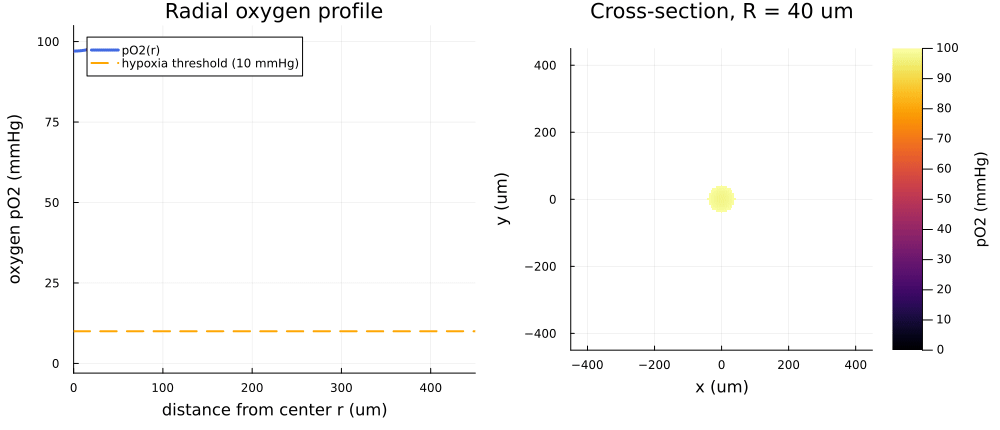

In [6]:
mkpath("figures")
Rmax = 450.0
grid = range(-Rmax, Rmax, length = 181)
θ    = range(0, 2π, length = 200)

anim = @animate for R in vcat(range(40, Rmax, length = 48), fill(Rmax, 8))   # hold the last frame
    rn, rh = necrotic_radius(R), hypoxic_radius(R)
    rr = range(0, R, length = 300)

    left = plot(rr, [pO2(r, R) for r in rr], lw = 3, color = :royalblue, label = "pO2(r)",
                xlims = (0, Rmax), ylims = (-3, 105), legend = :topleft,
                xlabel = "distance from center r (um)", ylabel = "oxygen pO2 (mmHg)",
                title = "Radial oxygen profile")
    hline!(left, [phyp], ls = :dash, color = :orange, label = "hypoxia threshold (10 mmHg)")
    rn > 0 && vspan!(left, [0, rn], color = :gray, alpha = 0.35, label = "necrotic core")

    Z = [(r = hypot(x, y); r <= R ? pO2(r, R) : NaN) for y in grid, x in grid]
    right = heatmap(grid, grid, Z, c = :inferno, clims = (0, p0), aspect_ratio = 1,
                    xlims = (-Rmax, Rmax), ylims = (-Rmax, Rmax), colorbar_title = "pO2 (mmHg)",
                    title = "Cross-section, R = $(round(Int, R)) um", xlabel = "x (um)", ylabel = "y (um)")
    rh > 0 && plot!(right, rh .* cos.(θ), rh .* sin.(θ), color = :orange, ls = :dash, lw = 2, label = "")
    rn > 0 && plot!(right, Shape(rn .* cos.(θ), rn .* sin.(θ)), color = :gray60, lw = 0, label = "")

    plot(left, right, layout = (1, 2), size = (1000, 430), bottom_margin = 6Plots.mm, left_margin = 5Plots.mm)
end
gif(anim, "figures/spheroid_oxygen.gif", fps = 8)

> **Post-understanding (summary).** Steady-state oxygen in a spheroid satisfies $r^2p'' + 2rp' = \kappa r^2$: the Cauchy–Euler operator plus a source term. Its solution $p = A + B/r + \kappa r^2/6$ has two regimes:
> * **Small spheroids:** the $1/r$ term must vanish (oxygen is finite at the center), oxygen dips parabolically toward the middle and the center runs out once $R$ reaches the diffusion limit $r_l = \sqrt{6p_0/\kappa}$, measured at about 233 µm by Grimes et al. (2014).
> * **Large spheroids:** the dead core removes $r = 0$ from the domain, the $1/r$ term returns and the core radius solves the cubic $R^3 - 3Rr_n^2 + 2r_n^3 = r_l^2R$ (Grimes et al.'s eq. 2.5, in different variables). The living rim approaches a fixed thickness of $r_l/\sqrt3 \approx 135$ µm.
>
> With the measured numbers, the center becomes hypoxic at about 221 µm and dies at 233 µm. An independent numerical solve reproduced the formula exactly. The same physics, hypoxia limiting how well radiation works, underlies MSK's FMISO-PET-guided dose de-escalation trial.

## 3. Story 2: The $1/r$ potential, Born solvation and OpenMM at MSK

> **Pre-understanding: the biology.** **Kinases** are enzymes that switch other proteins on or off by attaching phosphate groups, and many cancer drugs are **kinase inhibitors**: small molecules that sit in a kinase's binding pocket and block it. Whether a drug binds tightly, and to which kinases, depends on the forces between its atoms and the protein's atoms. **Molecular dynamics (MD)** simulates those atoms moving under Newton's laws, using a *force field* that adds up bond, van der Waals and **electrostatic** terms.
>
> **The MSK connection.** John Chodera's lab at MSK's Sloan Kettering Institute combines "theory, computation, and automated biophysical experiments" to build predictive models of drug binding, with a focus on "kinases and other cancer targets," and co-develops the GPU-accelerated **OpenMM** simulation framework ([choderalab.org](https://www.choderalab.org/jdc-bios); code at [github.com/choderalab](https://github.com/choderalab) and [github.com/openmm](https://github.com/openmm)). (Chodera also co-founded the drug-discovery startup Achira in 2024.)
>
> **Pre-understanding: the math.** Outside a point charge there is no other charge, so the electric potential $\varphi$ satisfies **Laplace's equation** $\nabla^2\varphi = 0$. By symmetry $\varphi$ depends only on $r$, which gives exactly the equation from Section 1: $r^2\varphi'' + 2r\varphi' = 0$.
>
> 🔴 **From another course: electrostatics.** Electric potential, Gauss's law and the dielectric constant $\varepsilon$ come from physics (electricity and magnetism); solvation free energy comes from chemistry. The notebook states each fact as it is used.

### 3.1 Deriving Coulomb's law from the Cauchy–Euler solution
* General solution (Section 1): $\varphi = A + B/r$.
* Far away the potential vanishes, $\varphi \to 0$ as $r \to \infty$, so $A = 0$.
* **Gauss's law** fixes $B$: the total electric flux through a sphere around charge $q$ is $q/\varepsilon_0$. With field $E = -\varphi' = B/r^2$: $4\pi r^2 \cdot B/r^2 = q/\varepsilon_0$, so $B = q/(4\pi\varepsilon_0)$.

$$
\varphi(r) = \frac{q}{4\pi\varepsilon_0\, r}, \qquad U(r) = q_2\,\varphi = \frac{1}{4\pi\varepsilon_0}\,\frac{q_1q_2}{r}.
$$
This is the Coulomb interaction energy exactly as OpenMM documents it for `NonbondedForce` without a cutoff ([OpenMM theory guide](https://docs.openmm.org/latest/userguide/theory/02_standard_forces.html)). In a uniform solvent with dielectric constant $\varepsilon$, the same derivation gives an extra factor $1/\varepsilon$; water's dielectric constant is about 78–80, which is why charges interact far more weakly in water.

OpenMM works in molecular units (charge in elementary charges $e$, distance in nm, energy in kJ/mol) and computes the constant $1/(4\pi\varepsilon_0)$ from $\varepsilon_0$ in its source file `SimTKOpenMMRealType.h` ([source](https://github.com/openmm/openmm/blob/master/platforms/reference/include/SimTKOpenMMRealType.h)). The cell below repeats that unit conversion.

1/(4πε0) = 138.9355 kJ·nm/(mol·e²)   (OpenMM's ONE_4PI_EPS0 ≈ 138.935)


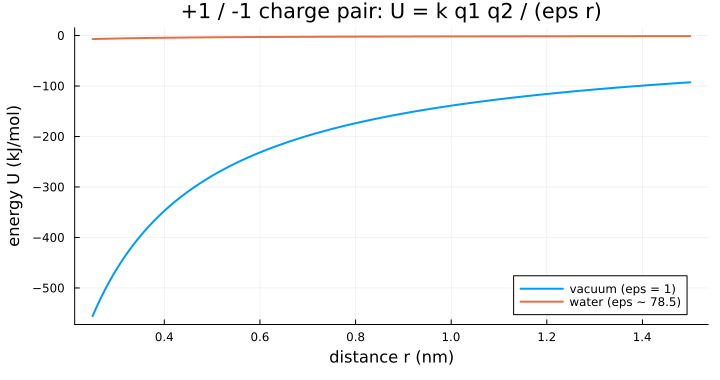

In [7]:
# SI constants (exact 2019 SI values for e and N_A; CODATA 2018 for ε0, the value OpenMM's source uses)
const e_charge = 1.602176634e-19      # C
const N_A      = 6.02214076e23        # 1/mol
const ε0       = 8.8541878128e-12     # F/m = C²/(J·m)

# 1/(4πε0) converted to kJ·nm/(mol·e²)
k_coul = (e_charge^2 * N_A) / (4π * ε0) / 1e-9 / 1e3
println("1/(4πε0) = ", round(k_coul, digits = 4), " kJ·nm/(mol·e²)   (OpenMM's ONE_4PI_EPS0 ≈ 138.935)")

coulomb(q1, q2, r; εr = 1.0) = k_coul * q1 * q2 / (εr * r)   # kJ/mol, r in nm

rs = range(0.25, 1.5, length = 200)
plot(rs, coulomb.(1, -1, rs), label = "vacuum (eps = 1)", xlabel = "distance r (nm)",
     ylabel = "energy U (kJ/mol)", title = "+1 / -1 charge pair: U = k q1 q2 / (eps r)")
plot!(rs, coulomb.(1, -1, rs; εr = 78.5), label = "water (eps ~ 78.5)")

### 3.2 Two regions, matched at a boundary: the Born model of solvation
> 🟡 **Coming later: boundary-value problems** again: one solution inside the ion, one outside, glued together at $r = a$.

Section 2 matched solutions across the edge of a necrotic core. The same idea gives one of the classic models of **solvation**, the energy change when a charged ion moves from vacuum into water.

Model an ion as a sphere of radius $a$ carrying charge $q$ on its surface, sitting in a solvent with dielectric constant $\varepsilon$. Both inside and outside, $\varphi$ solves $r^2\varphi'' + 2r\varphi' = 0$, so on each side $\varphi = A + B/r$:
* **Inside** ($r < a$): finite at the center, so $B_{\text{in}} = 0$ and $\varphi$ is constant.
* **Outside** ($r > a$): $\varphi \to 0$ at infinity, and Gauss's law in the solvent gives $\varphi = \dfrac{q}{4\pi\varepsilon_0\varepsilon\, r}$.
* **Matching** at $r = a$ (continuity) sets the inside constant to $\dfrac{q}{4\pi\varepsilon_0\varepsilon\, a}$.

The work needed to build up the charge is $W = \tfrac12 q\,\varphi(a) = \dfrac{q^2}{8\pi\varepsilon_0\varepsilon a}$. Subtracting the vacuum value ($\varepsilon = 1$) gives the **Born solvation energy**:
$$
\Delta G_{\text{Born}} = -\frac{q^2}{8\pi\varepsilon_0\, a}\left(1 - \frac{1}{\varepsilon}\right).
$$
It is negative: ions are strongly stabilized by water. **OpenMM connection:** OpenMM's implicit-solvent `GBSAOBCForce` uses a *generalized Born* energy of the form $-\tfrac12\big(\tfrac{1}{\varepsilon_{\text{solute}}} - \tfrac{1}{\varepsilon_{\text{solvent}}}\big)\sum_{i,j} q_iq_j/f_{\text{GB}}$, with the Coulomb constant absorbed into the units ([OpenMM theory guide](https://docs.openmm.org/latest/userguide/theory/02_standard_forces.html)). For a single isolated ion with $\varepsilon_{\text{solute}} = 1$, $f_{\text{GB}}$ reduces to the ion's Born radius and the formula is exactly the Born energy derived here. Simulations use this to model water around a drug and protein without simulating every water molecule.

ion radius a = 0.15 nm:  ΔG_Born(q = +1) = -457.2 kJ/mol
ion radius a = 0.2 nm:  ΔG_Born(q = +1) = -342.9 kJ/mol
ion radius a = 0.3 nm:  ΔG_Born(q = +1) = -228.6 kJ/mol
doubling the charge (q = +2, a = 0.2 nm): -1371.7 kJ/mol  (scales as q²)
φ just inside a: 8.8494

   φ just outside a: 8.8494


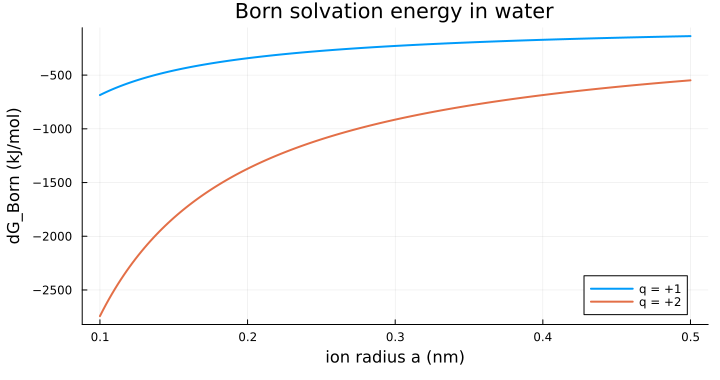

In [8]:
born(q, a; εr = 78.5) = -(k_coul / 2) * q^2 / a * (1 - 1 / εr)    # kJ/mol, a in nm

for a in (0.15, 0.20, 0.30)
    println("ion radius a = $a nm:  ΔG_Born(q = +1) = ", round(born(1, a), digits = 1), " kJ/mol")
end
println("doubling the charge (q = +2, a = 0.2 nm): ", round(born(2, 0.2), digits = 1), " kJ/mol  (scales as q²)")

# Check the matched solution numerically: potential is continuous at r = a and
# the field jumps only because of the surface charge.
a, εr = 0.2, 78.5
φ(r) = r < a ? k_coul / (εr * a) : k_coul / (εr * r)       # q = +1, in kJ/(mol·e)
println("φ just inside a: ", round(φ(a - 1e-9), digits = 4), "   φ just outside a: ", round(φ(a + 1e-9), digits = 4))

as = range(0.1, 0.5, length = 200)
plot(as, born.(1, as), label = "q = +1", xlabel = "ion radius a (nm)", ylabel = "dG_Born (kJ/mol)",
     title = "Born solvation energy in water")
plot!(as, born.(2, as), label = "q = +2")

> **Post-understanding (summary).** Laplace's equation for a radially symmetric potential is the Cauchy–Euler equation $r^2\varphi'' + 2r\varphi' = 0$, so the potential is $A + B/r$. Requiring $\varphi \to 0$ at infinity and applying Gauss's law turns this into Coulomb's law, $U = q_1q_2/(4\pi\varepsilon_0 r)$, the electrostatic term in OpenMM's `NonbondedForce`; in OpenMM's units the constant is 138.935 kJ·nm/(mol·e²), reproduced above from $\varepsilon_0$. Matching an inside solution to an outside solution at the ion's surface, the same move as at the necrotic-core boundary in Section 2, gives the Born solvation energy, the single-ion case of the generalized-Born model that OpenMM uses for implicit water. At MSK, the Chodera lab applies this simulation machinery to predict how drugs bind kinases and other cancer targets.

## 4. A real cancer protein: the ABL kinase and imatinib

> **Pre-understanding: the biology.** In **chronic myeloid leukemia (CML)**, a chromosome swap fuses the *BCR* and *ABL1* genes. The fusion protein BCR-ABL contains the **ABL tyrosine kinase** locked in the "on" state, which drives the leukemia. **Imatinib** (Gleevec) blocks it by sitting in the kinase's ATP-binding pocket; it was one of the first targeted cancer drugs (Weinberg, *The Biology of Cancer*, 3rd ed., Chapter 17). The crystal structure of the ABL kinase domain bound to imatinib, PDB entry [1IEP](https://www.rcsb.org/structure/1IEP), showed that imatinib "captures a specific inactive conformation" of the kinase (Nagar et al. 2002, *Cancer Research*).
>
> **Resistance.** Patients can relapse when ABL mutates. The best-known resistance mutation, **T315I** (threonine 315 replaced by isoleucine, the "gatekeeper" residue at the back of the pocket), was found in patients resistant to imatinib (Gorre et al. 2001, *Science*).
>
> **The MSK connections.**
> * The 1IEP structure paper was co-authored with Memorial Sloan-Kettering researchers (including B. Clarkson, W. G. Bornmann and D. R. Veach), alongside a companion paper in the same journal issue from MSK's Molecular Pharmacology and Chemistry Program (Wisniewski et al. 2002, *Cancer Research*).
> * The Chodera lab at MSK used physics-based **alchemical free-energy calculations** (built on force fields like the one in Section 3) to predict how 144 clinically observed ABL mutations change the binding of eight FDA-approved kinase inhibitors, classifying mutations as resistant or susceptible with 88% accuracy (Hauser et al. 2018, *Communications Biology*).
> * Chodera and Seeliger's groups later found an ABL mutation that makes imatinib **unbind faster** without changing its overall affinity: a resistance mechanism based on binding *kinetics* (Lyczek et al. 2021, *PNAS*).
>
> **Pre-understanding: the math.** The $1/r$ solution of the Cauchy–Euler equation shows up twice here:
> 1. **Electrostatics in the pocket** (Section 3): the Coulomb energy between a charged group on the drug and a charged amino acid.
> 2. **The speed limit for binding:** a drug diffusing toward a protein obeys Laplace's equation outside a "capture sphere," and its radial form is again $r^2c'' + 2rc' = 0$. This gives the **Smoluchowski** diffusion-limited association rate, the fastest any drug could possibly find its target.

### 4.1 Loading the structure
The cell below downloads PDB entry 1IEP from the RCSB Protein Data Bank and reads the atom coordinates with a few lines of plain Julia (the PDB format stores each atom on a fixed-width line). The file contains two copies of the complex (chains A and B); chain A is used throughout.

In [9]:
using Downloads
isfile("1IEP.pdb") || Downloads.download("https://files.rcsb.org/download/1IEP.pdb", "1IEP.pdb")

struct PDBAtom
    record::String; name::String; resname::String; chain::Char; resnum::Int
    xyz::Vector{Float64}; element::String
end

pdb_atoms = [PDBAtom(strip(l[1:6]), strip(l[13:16]), strip(l[18:20]), l[22], parse(Int, l[23:26]),
                     [parse(Float64, l[31:38]), parse(Float64, l[39:46]), parse(Float64, l[47:54])], strip(l[77:78]))
             for l in eachline("1IEP.pdb") if startswith(l, "ATOM") || startswith(l, "HETATM")]

protein  = filter(a -> a.record == "ATOM" && a.chain == 'A', pdb_atoms)
imatinib = filter(a -> a.resname == "STI" && a.chain == 'A', pdb_atoms)    # "STI" = STI-571 = imatinib
println(length(protein), " protein atoms (residues ", protein[1].resnum, "–", protein[end].resnum, "), ",
        length(imatinib), " imatinib atoms")

# Which amino acids touch the drug? (any atom within 4 Å)
mindist(p) = minimum(norm(p.xyz - q.xyz) for q in imatinib)
contacts = unique([(a.resname, a.resnum) for a in protein if mindist(a) < 4.0])
println(length(contacts), " residues within 4 Å of imatinib: ", join(["$(r)$(n)" for (r, n) in contacts], ", "))

atom(res, nm) = only(filter(a -> a.resnum == res && a.name == nm, protein))
drugatom(nm)  = only(filter(a -> a.name == nm, imatinib))
d_T315 = norm(atom(315, "OG1").xyz - drugatom("N13").xyz)
d_D381 = norm(atom(381, "OD2").xyz - drugatom("N51").xyz)
println("Thr315 hydroxyl O to imatinib N13:        ", round(d_T315, digits = 2), " Å  (hydrogen-bond distance)")
println("Asp381 carboxylate O to imatinib N51:     ", round(d_D381, digits = 2), " Å  (charged group to charged group)")

2229 protein atoms (residues 

225–498), 37 imatinib atoms
21

 residues within 4 Å of imatinib: LEU248, TYR253, VAL256, ALA269, LYS271, GLU286, VAL289, MET290, VAL299, ILE313, THR315, PHE317, MET318, GLY321, ILE360, HIS361, ARG362, LEU370, ALA380, ASP381, PHE382
Thr315 hydroxyl O to imatinib N13:        2.88 Å  (hydrogen-bond distance)
Asp381 carboxylate O to imatinib N51:     4.86 Å  (charged group to charged group)


**Reading the output.** Two contacts matter for the math:
* **Thr315.** Its side-chain hydroxyl (OH) oxygen sits about 2.9 Å from imatinib's N13 nitrogen, a typical hydrogen-bond distance. In the T315I mutant, isoleucine has no hydroxyl group and a bulkier side chain, so this contact is lost.
* **Asp381.** Its negatively charged carboxylate sits about 4.9 Å from N51, the methylated nitrogen of imatinib's piperazine ring, which is commonly modeled as protonated (positively charged). That makes it a real pair of opposite charges for the $1/r$ Coulomb law.

### 4.2 The protein model
The animation rotates chain A of the structure. The colored line is the protein backbone (one point per amino acid, colored from the start of the chain to the end), imatinib is drawn as a stick model in its pocket, Thr315 and Asp381 are marked and the faint orange sphere is the **capture sphere** used in Section 4.4.

![Rotating model of the ABL kinase domain with imatinib bound (PDB 1IEP)](figures/abl_imatinib.gif)

The next cell regenerates the GIF and saves it to `figures/abl_imatinib.gif`.

Plots.AnimatedGif("figures/abl_imatinib.gif")
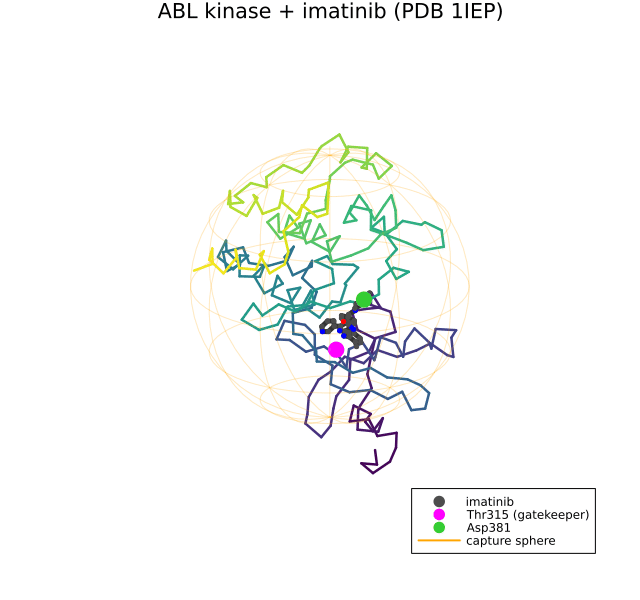

In [10]:
center = sum(a.xyz for a in protein) / length(protein)
Rg     = sqrt(sum(norm(a.xyz - center)^2 for a in protein) / length(protein))   # radius of gyration (Å)
R_prot = sqrt(5 / 3) * Rg            # radius of a uniform sphere with the same Rg

backbone = [a.xyz - center for a in protein if a.name == "CA"]
resnums  = [a.resnum for a in protein if a.name == "CA"]
drugxyz  = reduce(hcat, a.xyz - center for a in imatinib)
elcolor  = Dict("C" => :gray30, "N" => :blue, "O" => :red)
gk, asp  = atom(315, "OG1").xyz - center, atom(381, "OD2").xyz - center
t = range(0, 2π, length = 60)

anim = @animate for az in range(0, 350, length = 36)
    p = plot(getindex.(backbone, 1), getindex.(backbone, 2), getindex.(backbone, 3), line_z = resnums,
             c = :viridis, lw = 2.5, label = "", colorbar = false, camera = (az, 20), size = (640, 600),
             xlims = (-30, 30), ylims = (-30, 30), zlims = (-30, 30), aspect_ratio = :equal,
             framestyle = :none, ticks = false, axis = false, grid = false, legend = :bottomright,
             margin = -10Plots.mm, title = "ABL kinase + imatinib (PDB 1IEP)")
    for φ in range(0, π, length = 7)[2:end-1]          # capture sphere: latitude circles
        plot!(p, R_prot * sin(φ) .* cos.(t), R_prot * sin(φ) .* sin.(t), fill(R_prot * cos(φ), length(t)),
              color = :orange, alpha = 0.25, lw = 1, label = "")
    end
    for λ in range(0, π, length = 7)[1:end-1]          # capture sphere: meridians
        plot!(p, R_prot .* sin.(t) .* cos(λ), R_prot .* sin.(t) .* sin(λ), R_prot .* cos.(t),
              color = :orange, alpha = 0.25, lw = 1, label = "")
    end
    for i in 1:size(drugxyz, 2), j in i+1:size(drugxyz, 2)     # imatinib bonds: atom pairs closer than 1.9 Å
        norm(drugxyz[:, i] - drugxyz[:, j]) < 1.9 &&
            plot!(p, drugxyz[1, [i, j]], drugxyz[2, [i, j]], drugxyz[3, [i, j]], color = :gray20, lw = 5, label = "")
    end
    scatter!(p, drugxyz[1, :], drugxyz[2, :], drugxyz[3, :], ms = 3, mc = [elcolor[a.element] for a in imatinib],
             msw = 0, label = "imatinib")
    scatter!(p, [gk[1]], [gk[2]], [gk[3]], ms = 9, mc = :magenta, msw = 0, label = "Thr315 (gatekeeper)")
    scatter!(p, [asp[1]], [asp[2]], [asp[3]], ms = 9, mc = :limegreen, msw = 0, label = "Asp381")
    plot!(p, [NaN], [NaN], [NaN], color = :orange, label = "capture sphere")
end
gif(anim, "figures/abl_imatinib.gif", fps = 9)

### 4.3 Coulomb's law in the pocket
Using the $U = \dfrac{1}{4\pi\varepsilon_0}\dfrac{q_1q_2}{\varepsilon r}$ result from Section 3 with $q_1 = +1$ (imatinib's N51), $q_2 = -1$ (Asp381) and the measured distance, the cell below compares three surroundings: vacuum ($\varepsilon = 1$), a typical protein interior ($\varepsilon \approx 4$) and water ($\varepsilon \approx 78.5$). This is a deliberately simple two-point-charge estimate; a force field such as OpenMM's assigns a partial charge to every atom and sums all the $1/r$ terms.

In [11]:
r_pair = d_D381 / 10      # Å → nm
for (where, εr) in (("vacuum", 1.0), ("protein interior", 4.0), ("water", 78.5))
    println(rpad(where, 18), "eps = ", rpad(εr, 6), " U = ", round(coulomb(1, -1, r_pair; εr = εr), digits = 1), " kJ/mol")
end

vacuum            eps = 

1.0    U = -285.8 kJ/mol
protein interior  eps = 4.0    U = -71.5 kJ/mol
water             eps = 78.5   U = -3.6 kJ/mol


The same pair of charges is worth hundreds of kJ/mol in vacuum but only a few kJ/mol if fully exposed to water. Whether a charged contact helps a drug bind therefore depends on how well the pocket shields it from water, which is exactly why simulations need a careful model of the solvent (explicit water molecules, or the generalized-Born model from Section 3.2).

### 4.4 The speed limit for binding (Smoluchowski)
Before a drug can bind, it has to *find* the protein by diffusion. Treat the protein and drug as spheres that bind on contact, at center-to-center distance $R = R_{\text{protein}} + R_{\text{drug}}$, with relative diffusion coefficient $D = D_{\text{protein}} + D_{\text{drug}}$. At steady state, the drug concentration $c(r)$ around the protein satisfies Laplace's equation with two boundary conditions (Galanti et al. 2018, eqs. 2a–2c):
$$
\nabla^2 c = 0 \;\Longleftrightarrow\; r^2c'' + 2rc' = 0, \qquad c(R) = 0 \ \text{(every drug molecule that touches binds)}, \qquad c(\infty) = c_B .
$$
The Cauchy–Euler solution $c = A + B/r$ with these conditions gives
$$
c(r) = c_B\left(1 - \frac{R}{r}\right).
$$
The rate at which drug molecules arrive is the diffusive flux through the capture sphere, $4\pi R^2 \cdot D\,c'(R) = 4\pi R^2 \cdot D\,c_B/R$, so the association rate constant is
$$
k_{\text{on}} = 4\pi D R \qquad\text{(Smoluchowski, 1917).}
$$
> 🟡 **Boundary-value problem** (conditions at $r = R$ and as $r \to \infty$). 🔴 **From another course:** diffusion coefficients, Fick's law and the Stokes–Einstein relation come from physical chemistry and biophysics.

The cell below estimates every input from the structure: each molecule's radius from its radius of gyration, and each diffusion coefficient from the **Stokes–Einstein** relation $D = k_BT/(6\pi\eta r)$ for a sphere of radius $r$ in water.

protein radius ≈ 25.3

 Å,  imatinib radius ≈ 8.6 Å
D_protein ≈ 9.7e-11 m²/s,  D_imatinib ≈ 2.8e-10 m²/s
Smoluchowski ceiling k_on = 4πDR ≈ 9.8e9 M⁻¹ s⁻¹


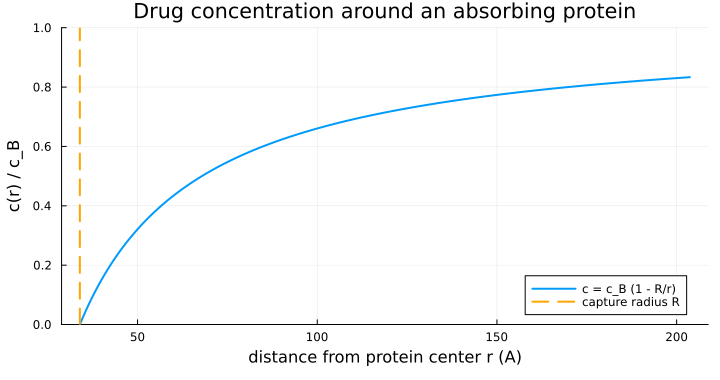

In [12]:
kB, T, η = 1.380649e-23, 298.15, 0.89e-3        # J/K, K (25 °C), Pa·s (water at 25 °C)
cdrug  = sum(a.xyz for a in imatinib) / length(imatinib)
R_drug = sqrt(5 / 3) * sqrt(sum(norm(a.xyz - cdrug)^2 for a in imatinib) / length(imatinib))

stokes_einstein(r_Å) = kB * T / (6π * η * r_Å * 1e-10)            # m²/s
D_rel  = stokes_einstein(R_prot) + stokes_einstein(R_drug)
R_cap  = (R_prot + R_drug) * 1e-10                                 # m
k_on   = 4π * D_rel * R_cap * N_A * 1e3                            # m³/s per molecule → L/(mol·s) = M⁻¹ s⁻¹

println("protein radius ≈ ", round(R_prot, digits = 1), " Å,  imatinib radius ≈ ", round(R_drug, digits = 1), " Å")
println("D_protein ≈ ", round(stokes_einstein(R_prot), sigdigits = 2), " m²/s,  D_imatinib ≈ ",
        round(stokes_einstein(R_drug), sigdigits = 2), " m²/s")
println("Smoluchowski ceiling k_on = 4πDR ≈ ", round(k_on, sigdigits = 2), " M⁻¹ s⁻¹")

rr = range(R_cap * 1e10, 6 * R_cap * 1e10, length = 200)          # Å
plot(rr, 1 .- (R_cap * 1e10) ./ rr, xlabel = "distance from protein center r (A)", ylabel = "c(r) / c_B",
     label = "c = c_B (1 - R/r)", title = "Drug concentration around an absorbing protein", ylims = (0, 1))
vline!([R_cap * 1e10], ls = :dash, color = :orange, label = "capture radius R")

> **Post-understanding (summary).** The ABL kinase–imatinib complex (PDB 1IEP), a structure solved with MSK co-authors and a target the Chodera lab at MSK has modeled for resistance mutations, shows the $1/r$ solution at work in two ways:
> * **Electrostatics:** imatinib's charged piperazine nitrogen sits about 4.9 Å from the charged Asp381. Coulomb's law gives an attraction of hundreds of kJ/mol in vacuum, tens in a protein interior and only a few in water, so the surroundings decide how much a charged contact matters. The gatekeeper Thr315 hydrogen-bonds to imatinib at about 2.9 Å, the contact the T315I resistance mutation removes.
> * **Binding speed:** Laplace's equation outside a capture sphere is the Cauchy–Euler equation, and its solution $c = c_B(1 - R/r)$ gives the Smoluchowski rate $k_{\text{on}} = 4\pi DR$. Using radii from the structure and Stokes–Einstein diffusion, the ceiling is about $10^{10}$ M⁻¹ s⁻¹. Real binding is slower, because only a small patch of the protein surface is the pocket and imatinib must catch ABL in a specific inactive conformation (Nagar et al. 2002). Binding kinetics matter clinically: one ABL resistance mutation works by making imatinib unbind faster (Lyczek et al. 2021).

## 5. Wrap-up: one equation, two stories

> **Pre-understanding.** Both stories started from $r^2y'' + 2ry' = (\text{source})$ with general homogeneous solution $A + B/r$. What changed was the physics deciding which constants survive.

| | Story 1: oxygen in a spheroid | Story 2: potential around an ion |
|---|---|---|
| Equation | $r^2p'' + 2rp' = \kappa r^2$ (Poisson, consumption) | $r^2\varphi'' + 2r\varphi' = 0$ (Laplace, no charge) |
| Constant solution $A$ | the oxygen level set by the surface | the reference potential; $0$ at infinity |
| $1/r$ solution | thrown out if the center is alive; **needed** once a necrotic core appears | **the whole answer**: Coulomb's law |
| Matching across a boundary | living rim ↔ dead core at $r_n$ | ion interior ↔ solvent at $r = a$ |
| Cancer relevance | hypoxia, necrosis, radiation resistance; MSK's FMISO-PET dose trial | MD simulations of kinase inhibitors; OpenMM, Chodera lab at MSK; ABL–imatinib (Section 4) |

**Where else the Cauchy–Euler equation appears in computational biology.** It is essentially absent from sequence-based bioinformatics (alignment, variant calling, expression analysis), but it appears wherever something diffuses toward or away from a center, and as a building block of series solutions:

| Setting | How the equation enters |
|---|---|
| Drug or ligand binding a protein | Smoluchowski's diffusion-limited rate $k_{\text{on}} = 4\pi DR$, from $c = c_B(1 - R/r)$ (Section 4.4; Galanti et al. 2018) |
| How cells sense chemicals | Berg & Purcell (1977) used the same diffusion-to-a-sphere solution, extended to a cell covered with small receptor patches |
| Oxygen around a single blood vessel | In 2-D (a cylinder), the radial Laplacian gives $r^2y'' + ry' = 0$, with solutions $1$ and $\ln r$ (Exercise 2) |
| Population genetics | Kimura's (1955) diffusion model of random genetic drift has *regular singular points* at allele frequencies 0 and 1. Power-series (Frobenius) solutions near such points start from a Cauchy–Euler-type indicial equation. 🟡 Series solutions near singular points usually come later in a first ODE course, often under the heading "Cauchy–Euler equations, revisited" |

> **Post-understanding (summary).** The Cauchy–Euler equation is not a cancer-genomics tool, but it is the radial form of the 3-D Laplacian, and that makes it part of the physics of tumors and of drug design. Its two solutions, a constant and $1/r$, describe oxygen in a growing tumor spheroid (with boundary conditions deciding when the $1/r$ term is allowed), the Coulomb potential that molecular simulations use when modeling cancer drugs and the diffusion-limited speed at which a drug such as imatinib can find its target protein.

## 6. Exercises

1. **Repeated root.** Solve $x^2y'' - xy' + y = 0$. *(Hint: the indicial equation is $(m-1)^2 = 0$.)* Check the answer with the solver from Section 1.
2. **A tumor cord in 2-D.** Around a single blood vessel, tumor tissue forms a cylinder (a *tumor cord*), and the radial Laplacian in 2-D is $y'' + \tfrac1r y'$. Show that $r^2y'' + ry' = 0$ has a repeated indicial root and general solution $A + B\ln r$. Why is the $\ln r$ term allowed here even though it blows up at $r = 0$? *(Hint: what occupies the center of the cylinder?)*
3. **Hypoxia onset.** Using $p_0 = 100$ mmHg and $r_l = 233$ µm, show by hand that the center of a spheroid first becomes hypoxic (10 mmHg) at $R = r_l\sqrt{0.9} \approx 221$ µm. Confirm it with `pO2`.
4. **Sensitivity.** Grimes et al. report $r_l = 233 \pm 22$ µm. Recompute the necrotic-core radius for a 400 µm spheroid at $r_l = 211$ and $255$ µm. How sensitive is the dead-core size to the measured diffusion limit?
5. **Born energy inside a protein.** Protein interiors have a dielectric constant of only about 2–4. Compute $\Delta G_{\text{Born}}$ for a $+1$ charge with $a = 0.2$ nm at $\varepsilon = 4$ and compare it with water ($\varepsilon \approx 78.5$). What does this suggest about burying a charged group of a drug inside a binding pocket?
6. **The gatekeeper mutation.** Using the 1IEP coordinates, list every imatinib atom within 4 Å of any Thr315 atom. Which of those contacts involve the side-chain hydroxyl oxygen `OG1`, which isoleucine lacks? *(This is a geometric sketch of why T315I causes resistance, not a free-energy calculation.)*
7. **Smoluchowski sensitivity.** The capture radius here treats the whole protein surface as reactive. If only a patch of the surface counts, the rate drops. Recompute $k_{\text{on}}$ if the effective capture radius is just the pocket size, about 5 Å, and compare with the ceiling.

In [13]:
# Space for the exercises.

## 7. References

**Cauchy and the mathematics**
* O'Connor, J. J. & Robertson, E. F. *Augustin Louis Cauchy*. MacTutor History of Mathematics. https://mathshistory.st-andrews.ac.uk/Biographies/Cauchy/
* O'Connor, J. J. & Robertson, E. F. *Matrices and determinants*. MacTutor History of Mathematics. https://mathshistory.st-andrews.ac.uk/HistTopics/Matrices_and_determinants/
* Wikipedia: [Cauchy–Euler equation](https://en.wikipedia.org/wiki/Cauchy%E2%80%93Euler_equation), [Cauchy–Schwarz inequality](https://en.wikipedia.org/wiki/Cauchy%E2%80%93Schwarz_inequality), [Root test](https://en.wikipedia.org/wiki/Root_test), [Cauchy condensation test](https://en.wikipedia.org/wiki/Cauchy_condensation_test), [Picard–Lindelöf theorem](https://en.wikipedia.org/wiki/Picard%E2%80%93Lindel%C3%B6f_theorem).

**Tumor spheroids and hypoxia**
* Greenspan, H. P. (1972). Models for the growth of a solid tumor by diffusion. *Studies in Applied Mathematics* 51(4), 317–340.
* Grimes, D. R., Kelly, C., Bloch, K. & Partridge, M. (2014). A method for estimating the oxygen consumption rate in multicellular tumour spheroids. *Journal of the Royal Society Interface* 11, 20131124. https://doi.org/10.1098/rsif.2013.1124 (open access: https://pmc.ncbi.nlm.nih.gov/articles/PMC3899881/)
* Lee, N. Y. et al. Phase II trial of FMISO PET hypoxia-guided radiation dose de-escalation in HPV-related oropharyngeal carcinoma, Memorial Sloan Kettering. *Journal of Clinical Oncology*. https://doi.org/10.1200/JCO.23.01308
* Weinberg, R. A. *The Biology of Cancer*, 3rd ed. Chapter 13 (tumor microenvironment and angiogenesis).

**The ABL kinase, imatinib and diffusion-limited binding**
* Nagar, B., Bornmann, W. G., Pellicena, P., Schindler, T., Veach, D. R., Miller, W. T., Clarkson, B. & Kuriyan, J. (2002). Crystal structures of the kinase domain of c-Abl in complex with the small molecule inhibitors PD173955 and imatinib (STI-571). *Cancer Research* 62(15), 4236–4243. Structure: https://www.rcsb.org/structure/1IEP
* Wisniewski, D. et al. (2002). Characterization of potent inhibitors of the Bcr-Abl and the c-kit receptor tyrosine kinases. *Cancer Research* 62(15), 4244–4255 (Memorial Sloan-Kettering Cancer Center).
* Gorre, M. E. et al. (2001). Clinical resistance to STI-571 cancer therapy caused by BCR-ABL gene mutation or amplification. *Science* 293, 876–880. https://doi.org/10.1126/science.1062538
* Hauser, K., Negron, C., Albanese, S. K., Ray, S., Steinbrecher, T., Abel, R., Chodera, J. D. & Wang, L. (2018). Predicting resistance of clinical Abl mutations to targeted kinase inhibitors using alchemical free-energy calculations. *Communications Biology* 1, 70.
* Lyczek, A. et al. (2021). Mutation in Abl kinase with altered drug-binding kinetics indicates a novel mechanism of imatinib resistance. *PNAS* 118. https://doi.org/10.1073/pnas.2111451118
* Galanti, M., Fanelli, D., Traytak, S. D. & Piazza, F. (2018). Diffusion to capture and the concept of diffusive interactions. arXiv:1807.01378. https://arxiv.org/abs/1807.01378
* Berg, H. C. & Purcell, E. M. (1977). Physics of chemoreception. *Biophysical Journal* 20(2), 193–219.
* Kimura, M. (1955). Solution of a process of random genetic drift with a continuous model. *PNAS* 41(3), 144–150. https://pmc.ncbi.nlm.nih.gov/articles/PMC528040
* Weinberg, R. A. *The Biology of Cancer*, 3rd ed. Chapter 17 (rational treatment of cancer).

**Electrostatics, simulation and MSK**
* OpenMM User Guide, *Standard Forces* (NonbondedForce Coulomb term; GBSAOBCForce generalized Born). https://docs.openmm.org/latest/userguide/theory/02_standard_forces.html
* OpenMM source, `SimTKOpenMMRealType.h` (definition of `ONE_4PI_EPS0`). https://github.com/openmm/openmm/blob/master/platforms/reference/include/SimTKOpenMMRealType.h
* Chodera lab, Memorial Sloan Kettering Cancer Center. https://www.choderalab.org/ · https://github.com/choderalab
* Memorial Sloan Kettering public code: https://github.com/mskcc